In [12]:
!pip install matplotlib numpy scipy pandas seaborn scikit-learn torch --index-url https://download.pytorch.org/whl/cu121  

Looking in indexes: https://download.pytorch.org/whl/cu121


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import os
import gc 
from concurrent.futures import ThreadPoolExecutor
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification



SEED = 13


/home1/ad_892/projects/infoops/.venv/lib64/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
df_language_proportions = pd.read_csv("language_proportions_by_dataset.csv")



for dataset in df_language_proportions['dataset'].unique():
    subset = df_language_proportions[df_language_proportions['dataset'] == dataset]
    print(f"Dataset: {dataset}")
    for _, row in subset.iterrows():
        print(f"  {row['language']}{" *" if row['language'] in ['ru','zh'] else ''}: {row['proportion']:.2f}%")    

Dataset: GRU_202012
  en: 54.05%
  ru *: 17.98%
  ar: 16.36%
  und: 10.19%
  uk: 0.27%
  bg: 0.26%
  cs: 0.23%
  es: 0.11%
  in: 0.07%
  ro: 0.07%
  sr: 0.07%
  de: 0.07%
  tr: 0.05%
  ca: 0.03%
  tl: 0.03%
  et: 0.02%
  ja: 0.02%
  fr: 0.02%
  fa: 0.02%
  fi: 0.01%
  pt: 0.01%
  pl: 0.01%
  da: 0.01%
  nl: 0.01%
  ur: 0.01%
  cy: 0.00%
  it: 0.00%
  sv: 0.00%
  ht: 0.00%
Dataset: IRA_202012
  en: 53.58%
  ru *: 15.11%
  es: 6.20%
  und: 3.38%
  tr: 3.08%
  fr: 1.63%
  cs: 0.53%
  bg: 0.20%
  uk: 0.17%
  de: 0.16%
  ro: 0.15%
  pt: 0.09%
  in: 0.09%
  ca: 0.08%
  it: 0.08%
  sk: 0.07%
  tl: 0.05%
  et: 0.04%
  da: 0.04%
  id: 0.04%
  pl: 0.03%
  fi: 0.03%
  nl: 0.03%
  sl: 0.03%
  lt: 0.02%
  sr: 0.02%
  cy: 0.02%
  hu: 0.01%
  ht: 0.01%
  el: 0.01%
  fa: 0.01%
  ar: 0.01%
  vi: 0.01%
  sv: 0.01%
  hr: 0.01%
  bs: 0.01%
  no: 0.00%
  eu: 0.00%
  ja: 0.00%
  hi: 0.00%
  lv: 0.00%
  ko: 0.00%
  ur: 0.00%
Dataset: armenia_202012
  ru *: 72.97%
  en: 20.71%
  uk: 1.77%
  und: 1.47%
  bg: 1

'''

In [4]:


# clean the total_dataset for languages proportions, tanking of the languages with less than 1% of the tweets of each dataset, ina memory optmized way, and save the cleaned dataset as a new pickle file
cleaned_datasets = []
for dataset in data_total['dataset'].unique():
    print(f"Cleaning dataset: {dataset}")
    subset = data_total[data_total['dataset'] == dataset]
    language_proportions = df_language_proportions[df_language_proportions['dataset'] == dataset]
    languages_to_keep = language_proportions[language_proportions['proportion'] >= 1.]['language'].tolist()
    cleaned_subset = subset[subset['tweet_language'].isin(languages_to_keep)]
    cleaned_datasets.append(cleaned_subset)
cleaned_df_total = pd.concat(cleaned_datasets, ignore_index=True)
cleaned_df_total.to_pickle("cleaned_total_dataset.pkl")



NameError: name 'data_total' is not defined

In [11]:
twitter_langs = [
    'fa', 'ar', 'und', 'en', 'iw', 'in', 'hi', 'ur', 'ru', 'bg', 'uk',
    'zh', 'es', 'pt', 'tl', 'th', 'tr', 'it', 'fr', 'ca', 'de', 'bn'
]

# Fix old Twitter codes
fixed_langs = [
    'he' if lang == 'iw' else
    'id' if lang == 'in' else
    lang
    for lang in twitter_langs
]

model_langs = {'en', 'ru', 'uk', 'de', 'es', 'ar', 'am', 'hi', 'zh',
               'it', 'fr', 'hin', 'he', 'ja', 'tt'}

not_covered = [lang for lang in fixed_langs if lang not in model_langs]


for dataset in df_language_proportions['dataset'].unique():
    subset = df_language_proportions[df_language_proportions['dataset'] == dataset]
    print(f"Dataset: {dataset}")
    for _, row in subset.iterrows():
        if row['proportion'] > 1. and row['language'] in not_covered:
            print(f"  {row['language']}{" *" if row['language'] in ['ru','zh'] else ''}: {row['proportion']:.2f}%")
print(not_covered)

Dataset: GRU_202012
  und: 10.19%
Dataset: IRA_202012
  und: 3.38%
  tr: 3.08%
Dataset: armenia_202012
  und: 1.47%
  bg: 1.45%
Dataset: bangladesh_201901_1
  bn: 79.06%
  und: 5.45%
Dataset: catalonia_201906_1
  ca: 50.87%
  und: 35.90%
Dataset: china_082019_1
  pt: 9.62%
  und: 3.86%
  tl: 1.02%
Dataset: china_082019_2
  und: 3.67%
  pt: 1.24%
  tl: 1.22%
Dataset: cuba_082020
  und: 2.66%
Dataset: ecuador_082019_1
  und: 3.07%
Dataset: egypt_uae_082019_1
  und: 1.52%
Dataset: ghana_nigeria_032020
  und: 6.42%
Dataset: ira
  und: 2.62%
Dataset: ira_092020
Dataset: iran_092020
  und: 15.18%
Dataset: iran_201901_1
  ur: 21.59%
  fa: 9.25%
  und: 5.33%
Dataset: iran_201906_2
  fa: 38.39%
  und: 3.99%
Dataset: iran_201906_3
  fa: 68.91%
  und: 5.83%
Dataset: iran_202012
  fa: 7.81%
  und: 2.80%
Dataset: iranian
  tr: 8.23%
  fa: 8.21%
  und: 3.81%
Dataset: qatar_082020
  und: 1.50%
Dataset: russia_201901_1
  und: 16.21%
Dataset: spain_082019_1
  und: 3.74%
Dataset: thailand_092020
  th: 9

In [ ]:
''' 
    use this model https://huggingface.co/FredZhang7/one-for-all-toxicity-v3/tree/main to do a toxicity analysis. find the mean and the standart deviaton of the tocicty of each language in each dataset.

''' 


device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("FredZhang7/one-for-all-toxicity-v3")
model = AutoModelForSequenceClassification.from_pretrained("FredZhang7/one-for-all-toxicity-v3").to(device)


texts = ["hello cody", "good morning ","I hate you fucking son of a bitch die now motherfucker"]
inputs = tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)
print(torch.softmax(outputs.logits, dim=1).cpu().numpy())



Loading weights: 100%|██████████| 201/201 [00:09<00:00, 20.44it/s]


[[1.0000000e+00 1.1611334e-08]
 [1.0000000e+00 5.8491012e-09]
 [1.6502820e-05 9.9998355e-01]]


In [9]:
if 'cleaned_df_total' not in locals():
    cleaned_df_total = pd.read_pickle("cleaned_total_dataset.pkl")


results = []
for dataset in cleaned_df_total['dataset'].unique():
    subset = cleaned_df_total[cleaned_df_total['dataset'] == dataset]
    print(f"Dataset: {dataset}")
    for language in subset['tweet_language'].unique():
        lang_subset = subset[subset['tweet_language'] == language].sample(n=min(1000, len(subset[subset['tweet_language'] == language])), random_state=SEED)  # Sample up to 1000 tweets for efficiency
        texts = lang_subset['tweet_text'].tolist()
        inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True).to(device)
        with torch.no_grad():
            outputs = model(**inputs)
        scores = torch.softmax(outputs.logits, dim=1)[:, 1].cpu().numpy()  # Assuming the second column is the toxicity score
        mean_score = np.mean(scores)
        median_score = np.median(scores)
        std_score = np.std(scores)
        print(f"  Language: {language}, Mean Toxicity: {mean_score:.4f}, Median Toxicity: {median_score:.4f}, Std Dev: {std_score:.4f}")
        results.append((dataset, language, mean_score, median_score, std_score, scores))


Dataset: iran_201906_2
  Language: fa, Mean Toxicity: 0.0197, Median Toxicity: 0.0000, Std Dev: 0.1266
  Language: ar, Mean Toxicity: 0.0617, Median Toxicity: 0.0000, Std Dev: 0.2249
  Language: und, Mean Toxicity: 0.0074, Median Toxicity: 0.0000, Std Dev: 0.0801
  Language: en, Mean Toxicity: 0.0047, Median Toxicity: 0.0000, Std Dev: 0.0543
  Language: iw, Mean Toxicity: 0.0003, Median Toxicity: 0.0000, Std Dev: 0.0051
Dataset: ghana_nigeria_032020
  Language: en, Mean Toxicity: 0.0334, Median Toxicity: 0.0000, Std Dev: 0.1465
  Language: und, Mean Toxicity: 0.0289, Median Toxicity: 0.0000, Std Dev: 0.1399
Dataset: qatar_082020
  Language: ar, Mean Toxicity: 0.0488, Median Toxicity: 0.0000, Std Dev: 0.1953
  Language: und, Mean Toxicity: 0.0079, Median Toxicity: 0.0000, Std Dev: 0.0799
Dataset: iran_201901_1
  Language: ar, Mean Toxicity: 0.0280, Median Toxicity: 0.0000, Std Dev: 0.1347
  Language: en, Mean Toxicity: 0.0139, Median Toxicity: 0.0000, Std Dev: 0.0884
  Language: und, Me

results: make a plot of the values 
make a plot of the means
make a plot of the most toxicy languages 
make 

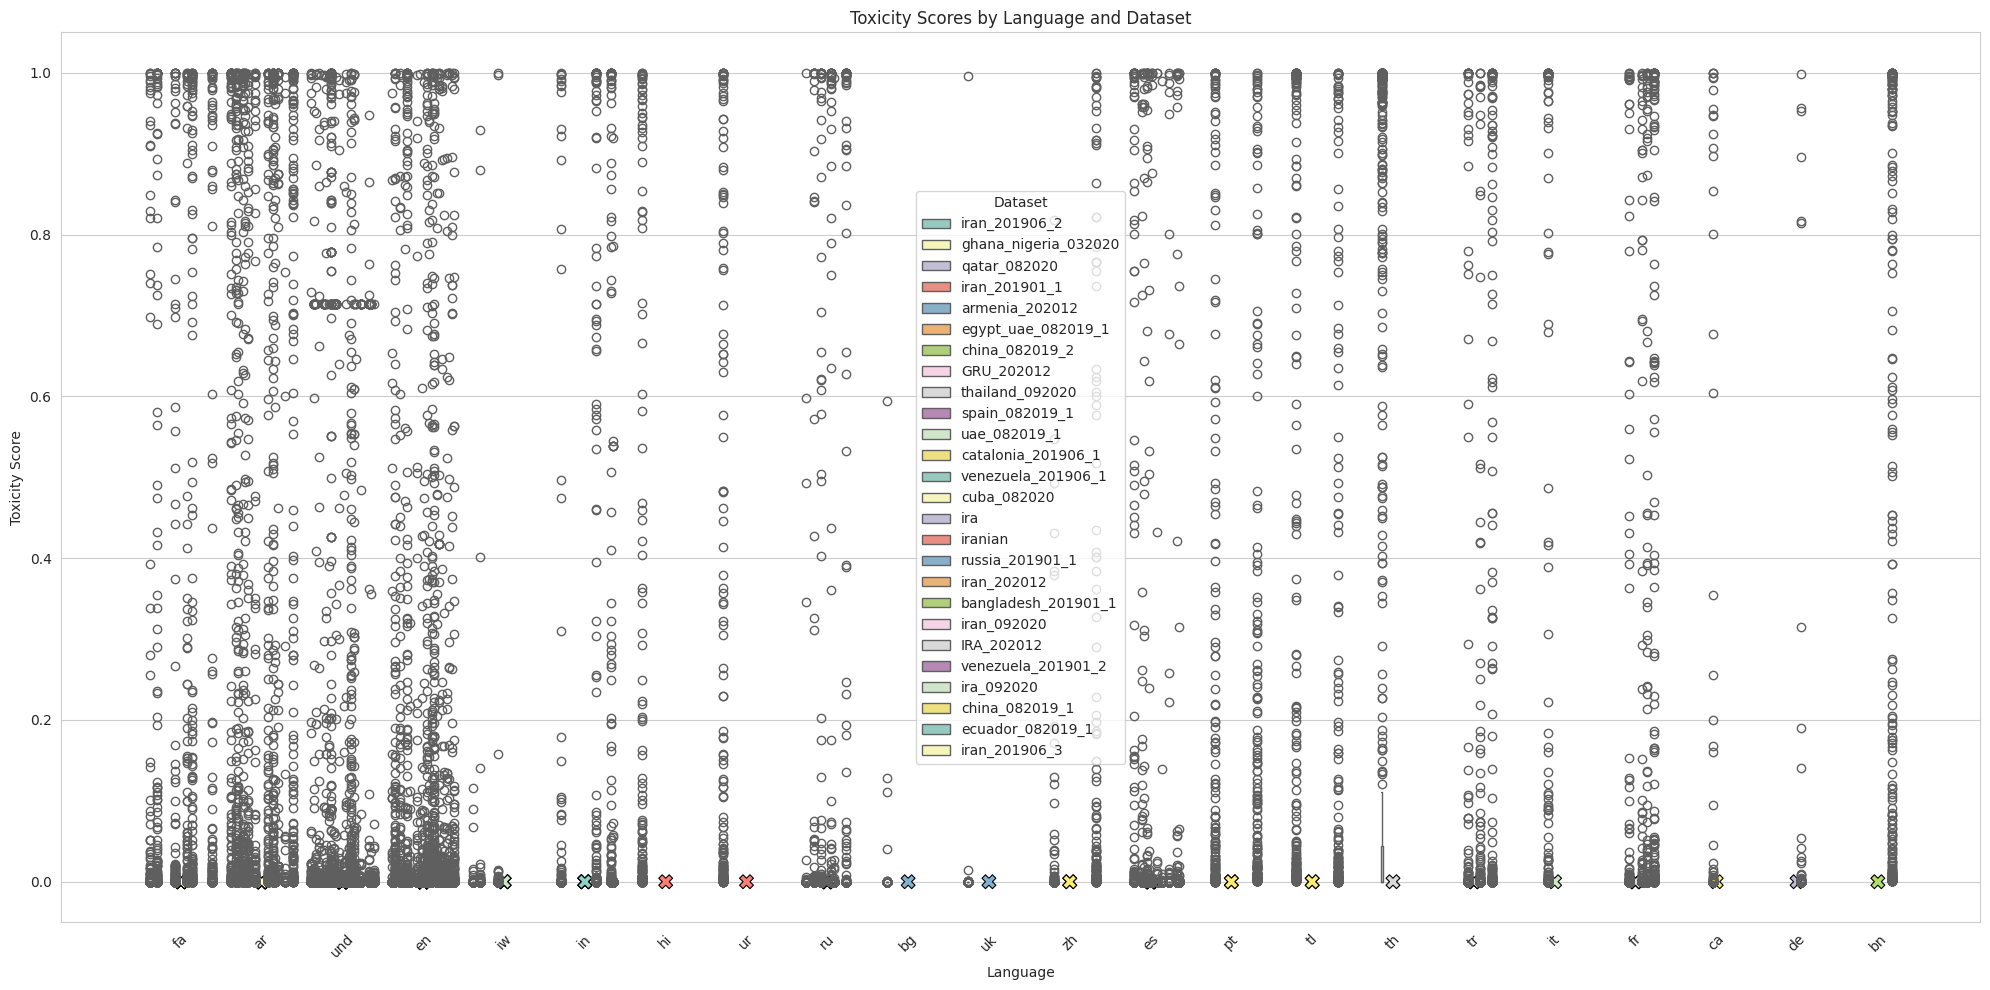

In [16]:
'''
 make a box plot of the toxicity scores of each language in each dataset, and save the plot as a png file. Show the points of each dataset in the box plot, and use different colors for each language. Also, show the mean each language in the box plot as a point, and use different shapes for the mean and median points. Save the plot as "toxicity_boxplot.png".

'''
results_df = pd.DataFrame(results, columns=['dataset', 'language', 'mean_toxicity', 'median_toxicity', 'std_toxicity', 'scores'])
plt.figure(figsize=(20,10 ))
sns.boxplot(x='language', y='scores', hue='dataset', data=results_df.explode('scores'), palette='Set3')
sns.scatterplot(x='language', y='median_toxicity', hue='dataset', data=results_df, marker='X', s=100, edgecolor='black', palette='Set3', legend=False)
plt.title("Toxicity Scores by Language and Dataset")
plt.xlabel("Language")
plt.ylabel("Toxicity Score")
plt.legend(title='Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("toxicity_boxplot.png")
plt.show()

In [43]:
results_df['scores'].apply(lambda x:  torch.tensor(x > 0.5, dtype=torch.float32).mean())

0      tensor(0.0190)
1      tensor(0.0610)
2      tensor(0.0070)
3      tensor(0.0050)
4          tensor(0.)
            ...      
106    tensor(0.0070)
107    tensor(0.0320)
108    tensor(0.0090)
109    tensor(0.0010)
110    tensor(0.0680)
Name: scores, Length: 111, dtype: object

In [52]:
suspicious_threshold = 0.5
results_df['toxicity_score'] = results_df['scores'].apply(lambda x:  torch.tensor(x > suspicious_threshold, dtype=torch.float32).mean().item())
results_df.iloc[36]['scores']


array([9.98110056e-01, 1.74884099e-05, 3.40213105e-02, 7.56033705e-06,
       1.60890477e-06, 9.99998569e-01, 2.40969848e-06, 4.06083203e-08,
       2.93328327e-07, 9.06042695e-01, 5.88311764e-08, 4.13630694e-08,
       3.11187614e-04, 6.38977587e-01, 7.11637256e-08, 8.72903526e-01,
       3.10600328e-08, 1.31073482e-02, 8.71138618e-05, 2.71621854e-08,
       7.28465524e-03, 5.94426366e-03, 1.17404998e-04, 9.07789513e-07,
       1.14621792e-03, 4.06806535e-08, 1.98311918e-05, 9.93138850e-01,
       1.01842727e-06, 6.08602502e-09, 1.41579912e-08, 6.29012717e-08,
       2.76315459e-05, 1.62981793e-01, 2.08261167e-03, 5.88449787e-08,
       7.62385083e-04, 8.34221601e-01, 9.94329035e-01, 1.34089336e-04,
       2.37060463e-04, 2.12250882e-07, 4.41707061e-06, 4.53772373e-06,
       9.94452178e-01, 5.66955750e-05, 8.00993741e-01, 1.76759414e-07,
       3.39599580e-07, 8.14525265e-06, 2.14857856e-08, 5.02102659e-04,
       6.04850792e-09, 9.70786550e-06, 2.32861540e-03, 3.37837155e-05,
      

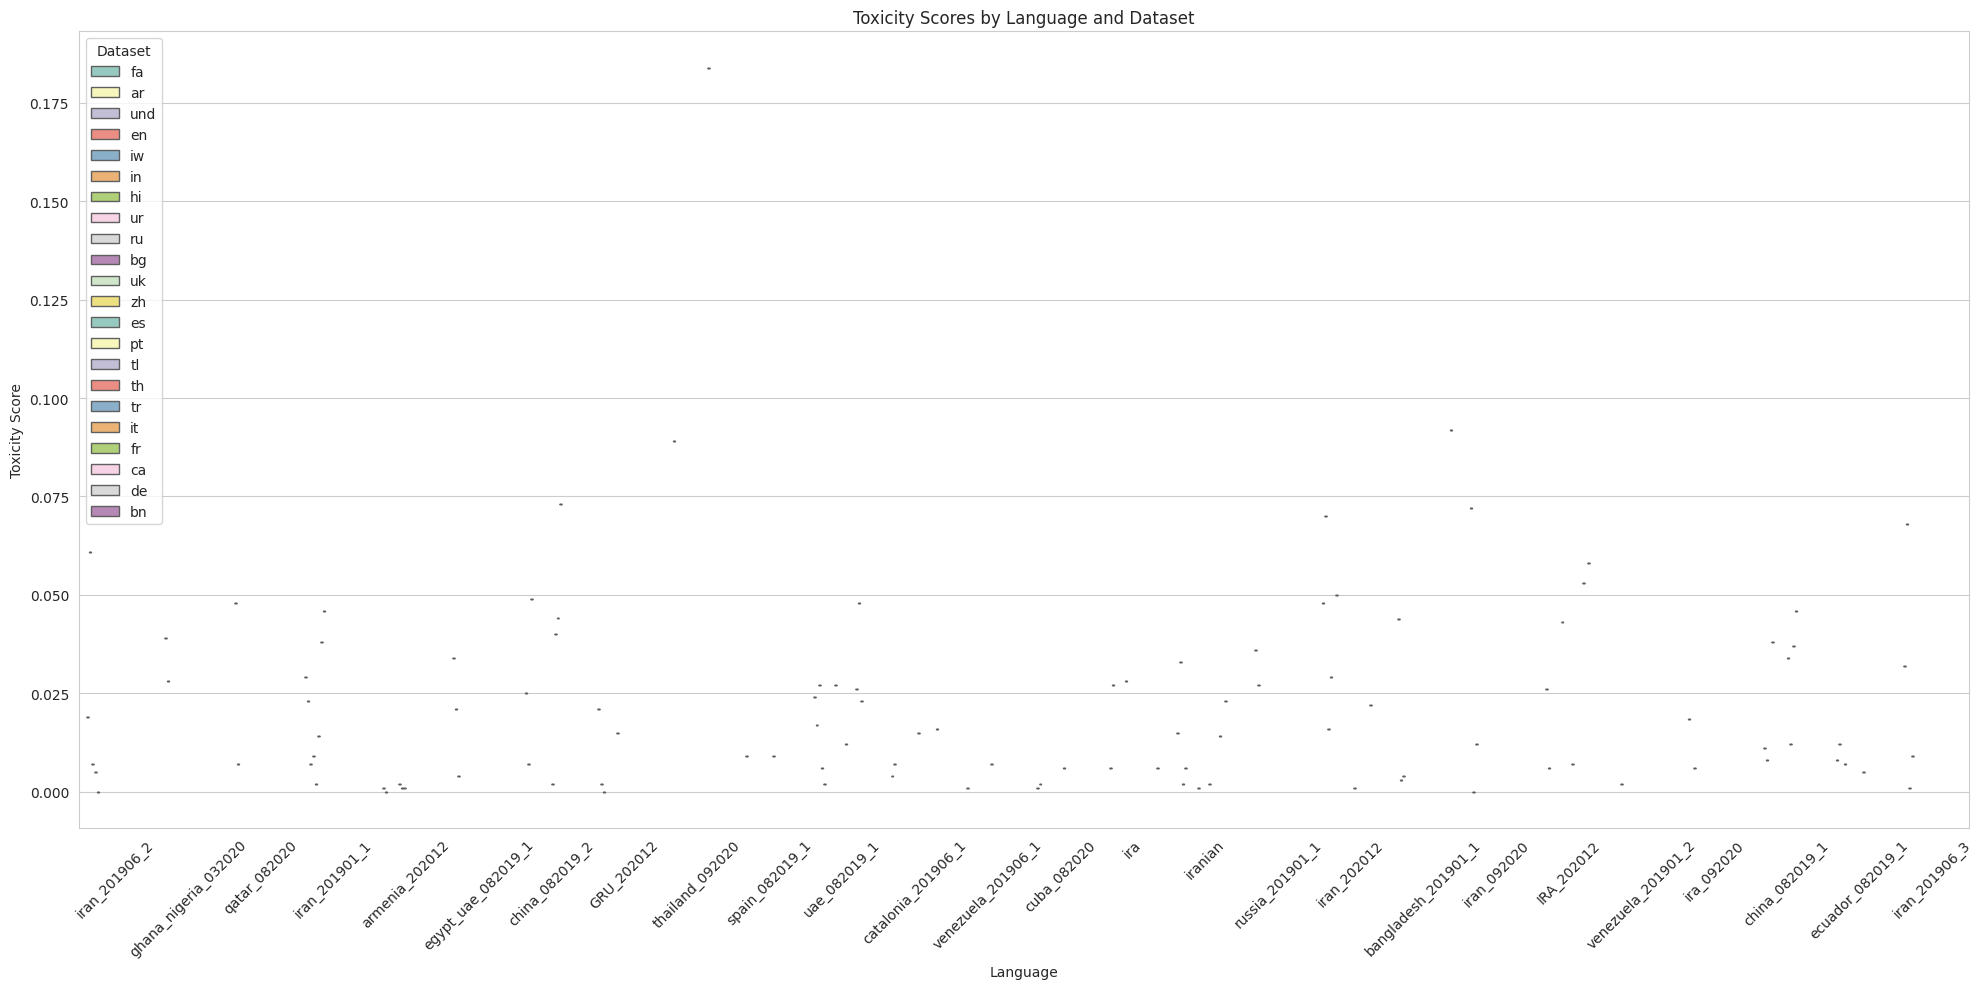

In [47]:
## make the same plot with the toxicity score instead of the scores, make the sma
plt.figure(figsize=(20,10 ))
sns.boxplot(x='dataset', y='toxicity_score', hue='language', data=results_df, palette='Set3')
plt.title("Toxicity Scores by Language and Dataset")
plt.xlabel("Language")
plt.ylabel("Toxicity Score")
plt.legend(title='Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

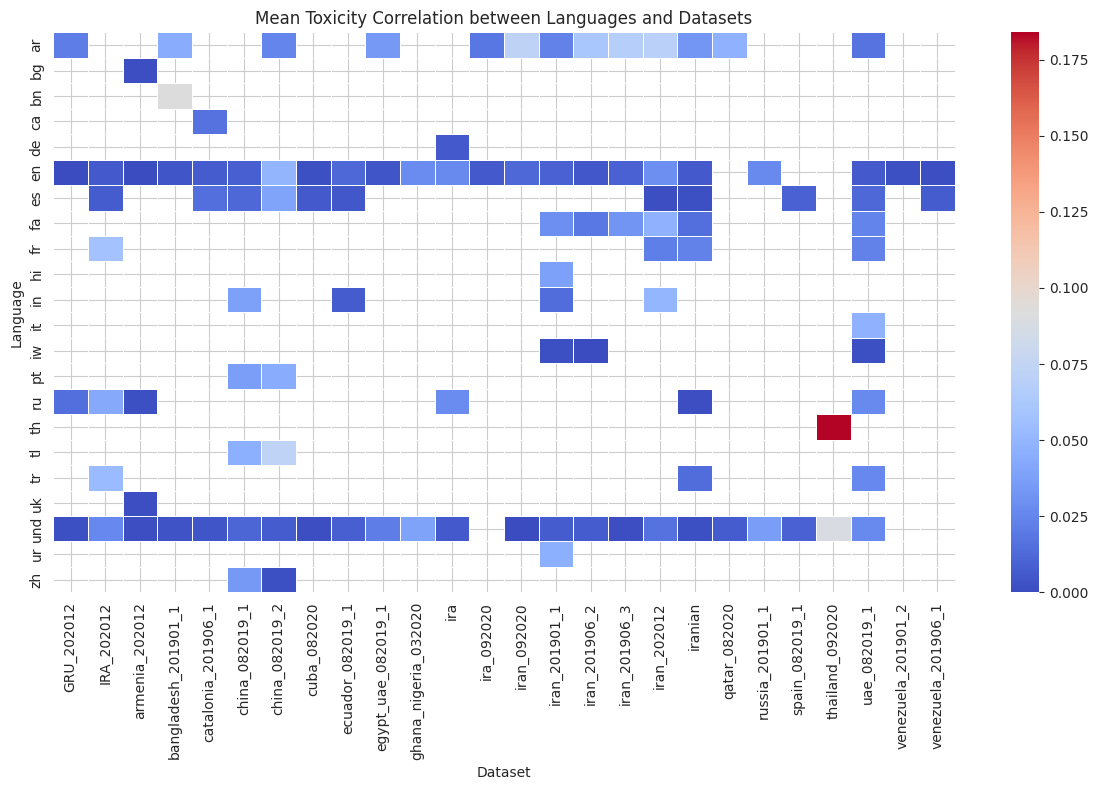

: 

In [ ]:
''' make a correlogram with languages and datastets. If there is no value, put the value as 0. ''' 
plt.figure(figsize=(12, 8))
correlation_data = results_df.pivot_table(index='language', columns='dataset', values='toxicity_score')
sns.heatmap(correlation_data, cmap='coolwarm', linewidths=.5)
plt.title("Mean Toxicity Correlation between Languages and Datasets")
plt.xlabel("Dataset")
plt.ylabel("Language")
plt.tight_layout()
plt.savefig("toxicity_correlogram.png")
plt.show()